##Imports

In [1]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Activation, BatchNormalization, Input
from keras.models import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from google.colab import drive

drive.mount("/content/drive")

x_train = tf.convert_to_tensor(np.load("/content/drive/MyDrive/BoneFracture/Train299X.npy"),dtype=np.float32)
y_train = np.load("/content/drive/MyDrive/BoneFracture/Train299Y.npy")

x_test = tf.convert_to_tensor(np.load("/content/drive/MyDrive/BoneFracture/Test299X.npy"),dtype=np.float32)
y_test = np.load("/content/drive/MyDrive/BoneFracture/Test299Y.npy")



reduce_lr = ReduceLROnPlateau(reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
))

Mounted at /content/drive


##InceptionResNetV2(2016)

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6846 - loss: 5.4195 - val_accuracy: 0.8057 - val_loss: 0.3850 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 44s 726ms/step - accuracy: 0.8795 - loss: 0.2801 - val_accuracy: 0.9210 - val_loss: 0.1798 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 549ms/step - accuracy: 0.9390 - loss: 0.1620 - val_accuracy: 0.9448 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 560ms/step - accuracy: 0.9579 - loss: 0.0982 - val_accuracy: 0.9638 - val_loss: 0.0959 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 538ms/step - accuracy: 0.9677 - loss: 0.0835 - val_accuracy: 0.9571 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 560ms/step - accuracy: 0.9682 - loss: 0.0786 - val_accuracy: 0.9571 - val_loss: 0.1278 - learning_rate: 0.0010
Epoch 7/100
61/61 ━━━━━━

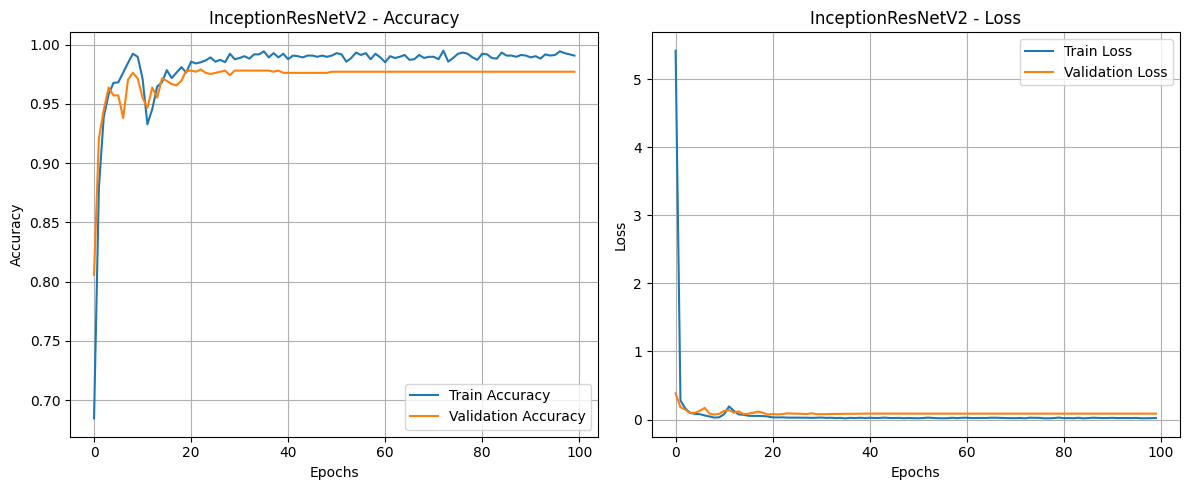

19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 953ms/step
CLASSIFICATION REPORT_____________________________________
              precision    recall  f1-score   support

           0       0.71      0.63      0.67       240
           1       0.77      0.83      0.80       360

    accuracy                           0.75       600
   macro avg       0.74      0.73      0.73       600
weighted avg       0.75      0.75      0.75       600



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 129,836,520 (495.29 MB)

 Trainable params: 25,166,594 (96.00 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 50,333,190 (192.01 MB)

In [2]:
from keras.applications import InceptionResNetV2

inception_resnet = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=x_train[0].shape)

for layer in inception_resnet.layers:
    layer.trainable = False

x = inception_resnet.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(np.unique(y_train)),activation='softmax')(x)

inception_resnet_model = Model(inputs=inception_resnet.input, outputs=predictions)


inception_resnet_model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=["accuracy"])
history = inception_resnet_model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.35,
    callbacks=[reduce_lr]
)
test_loss, test_acc = inception_resnet_model.evaluate(x_test, y_test, verbose=0)
test_acc *= 100
print(f'Test Accuracy: {test_acc:.2f}% | Test Loss: {test_loss:.4f}')


plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionResNetV2 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('InceptionResNetV2 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
y_pred = inception_resnet_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
print("CLASSIFICATION REPORT_____________________________________")
print(classification_report(y_test, y_pred))
inception_resnet_model.summary()




In [3]:
inception_resnet_model.save("/content/drive/MyDrive/BoneFracture/InceptionResNetV2A75L1.keras")